# Iirise lillede analüüs

## Impordid ja seadistused

In [10]:
!pip3 install pandas
!pip3 install duckdb
!pip3 install matplotlib
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
import xml


In [8]:
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Laeme sisse andmed

In [ ]:
iris = pd.read_csv("iris.csv")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
duckdb.sql("""
    SELECT *
    FROM 'iris.csv'
""").df()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## Avastuslik andmeanalüüs (*exploratory analysis*)

In [7]:
duckdb.sql("""
    SUMMARIZE iris
""").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,sepal_length,DOUBLE,4.3,7.9,35,5.843333333333335,0.8280661279778637,5.1,5.8,6.4,150,0.0
1,sepal_width,DOUBLE,2.0,4.4,26,3.057333333333334,0.4358662849366979,2.8,3.0,3.3249999999999997,150,0.0
2,petal_length,DOUBLE,1.0,6.9,39,3.7580000000000027,1.7652982332594664,1.5750000000000002,4.35,5.1,150,0.0
3,petal_width,DOUBLE,0.1,2.5,23,1.199333333333334,0.7622376689603467,0.3,1.3,1.8,150,0.0
4,species,VARCHAR,setosa,virginica,3,None,None,None,None,None,150,0.0


<Axes: xlabel='species', ylabel='count'>

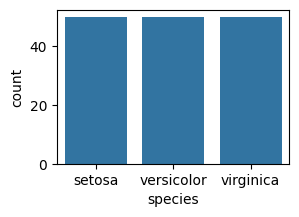

In [ ]:
fig = plt.figure(1, figsize=(3, 2))
sns.countplot(iris, x="species")

In [22]:
duckdb.sql("""
    SELECT species, count(*) AS count
    FROM iris
    GROUP BY species
""")

┌────────────┬───────┐
│  species   │ count │
│  varchar   │ int64 │
├────────────┼───────┤
│ virginica  │    50 │
│ setosa     │    50 │
│ versicolor │    50 │
└────────────┴───────┘

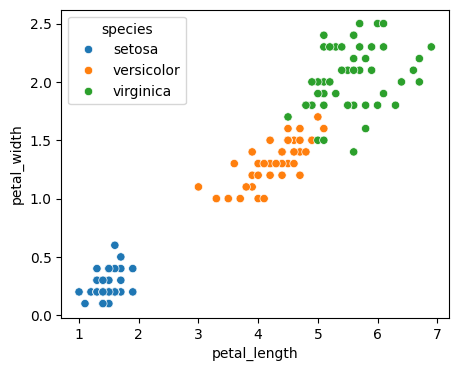

In [60]:
plt.figure(1, figsize=(5, 4))
sns.scatterplot(iris, x="petal_length", y="petal_width", hue="species");

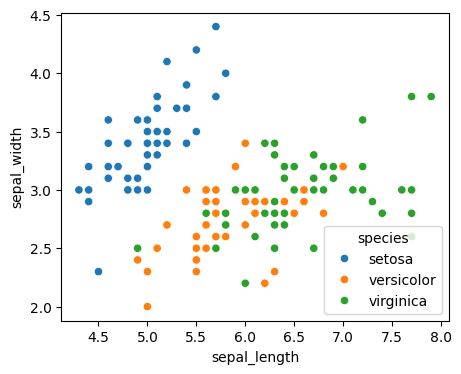

In [28]:
fig = plt.figure(1, figsize=(5, 4))
sns.scatterplot(iris, x="sepal_length", y="sepal_width", hue="species");

In [41]:
?sns.pairplot

Signature:
sns.pairplot(
    data,
    *,
    hue=None,
    hue_order=None,
    palette=None,
    vars=None,
    x_vars=None,
    y_vars=None,
    kind='scatter',
    diag_kind='auto',
    markers=None,
    height=2.5,
    aspect=1,
    corner=False,
    dropna=False,
    plot_kws=None,
    diag_kws=None,
    grid_kws=None,
    size=None,
)
Docstring:
Plot pairwise relationships in a dataset.

By default, this function will create a grid of Axes such that each numeric
variable in ``data`` will by shared across the y-axes across a single row and
the x-axes across a single column. The diagonal plots are treated
differently: a univariate distribution plot is drawn to show the marginal
distribution of the data in each column.

It is also possible to show a subset of variables or plot different
variables on the rows and columns.

This is a high-level interface for :class:`PairGrid` that is intended to
make it easy to draw a few common styles. You should use :class:`PairGrid`
directly if you

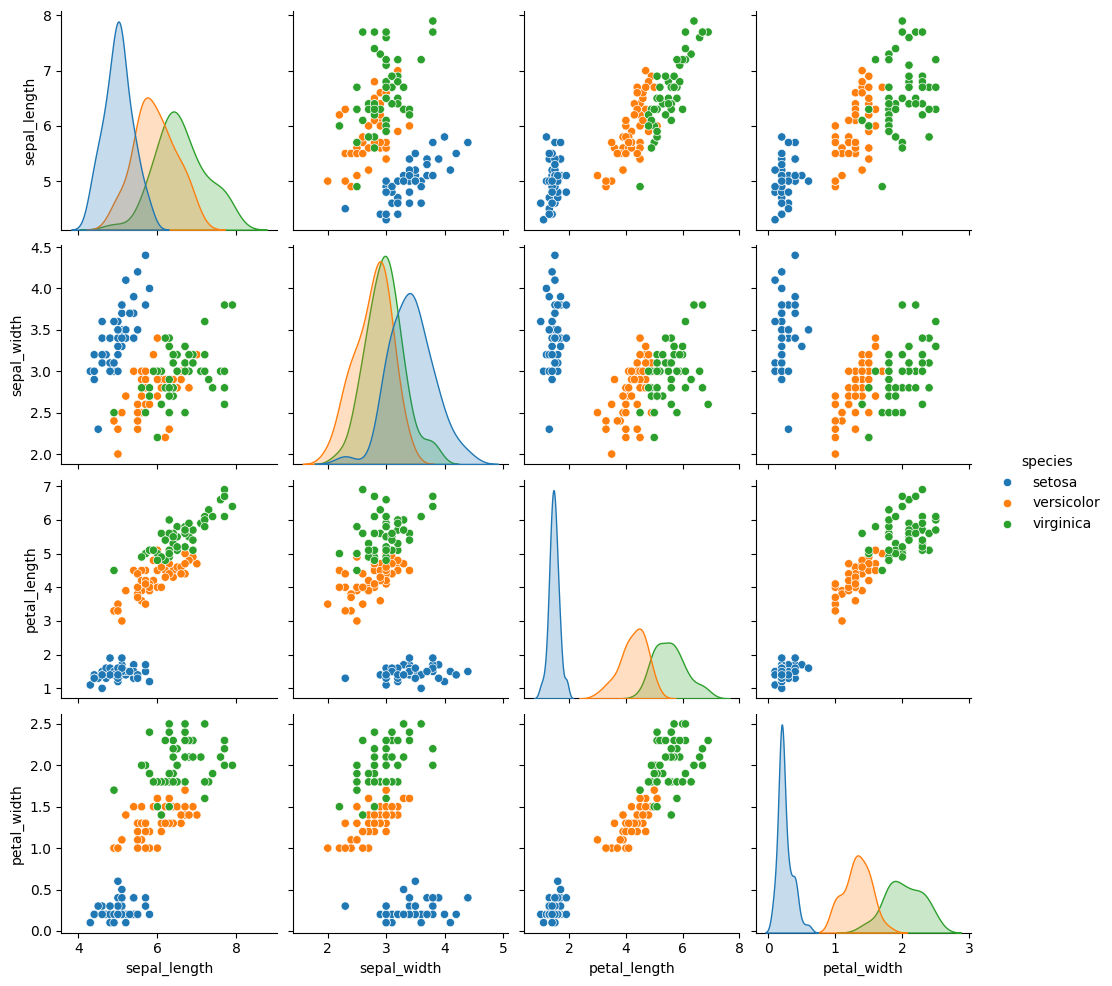

In [54]:
sns.pairplot(iris, hue="species")

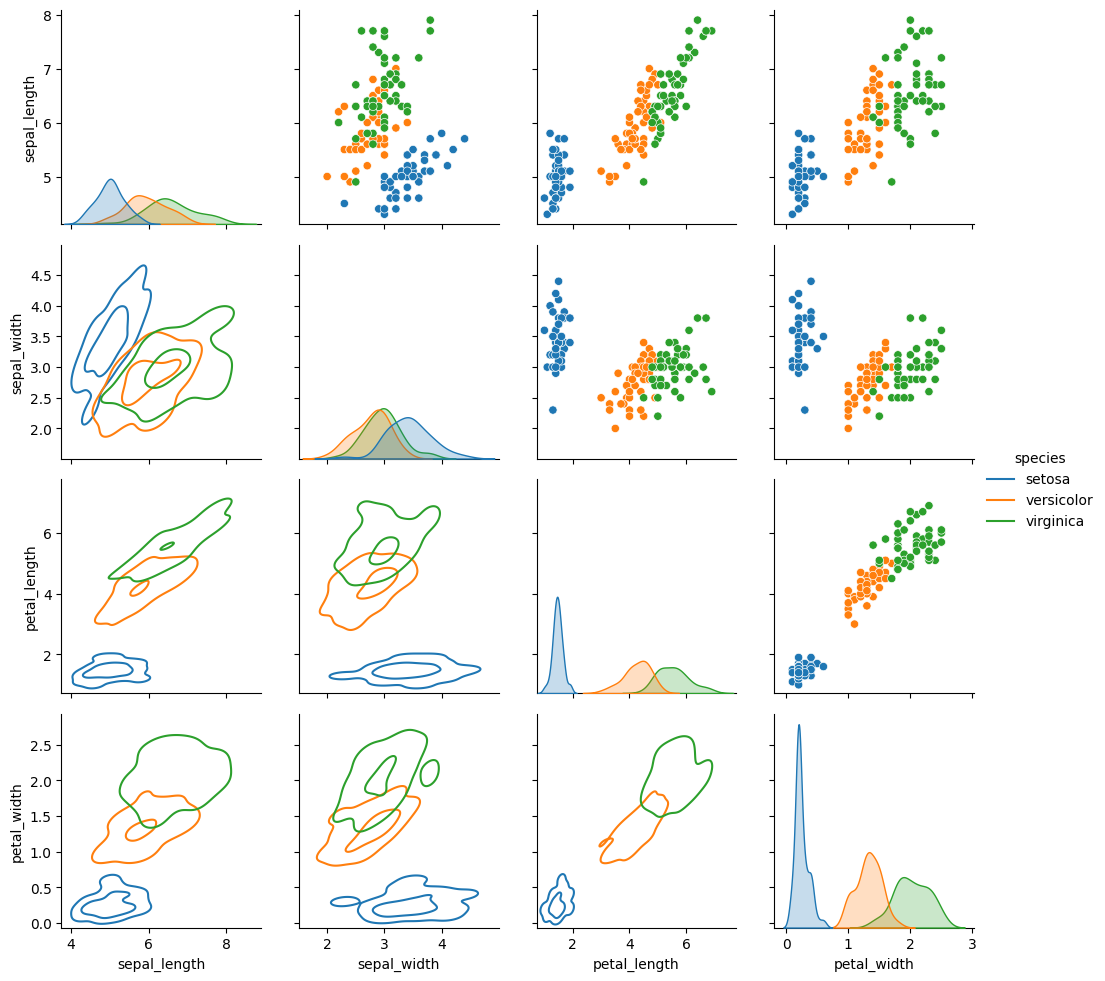

In [53]:
grid = sns.PairGrid(iris, hue="species")
grid.map_upper(sns.scatterplot)
grid.map_lower(sns.kdeplot, levels=3)
grid.map_diag(sns.kdeplot, fill=True)
grid.add_legend()

<Axes: xlabel='petal_length', ylabel='species'>

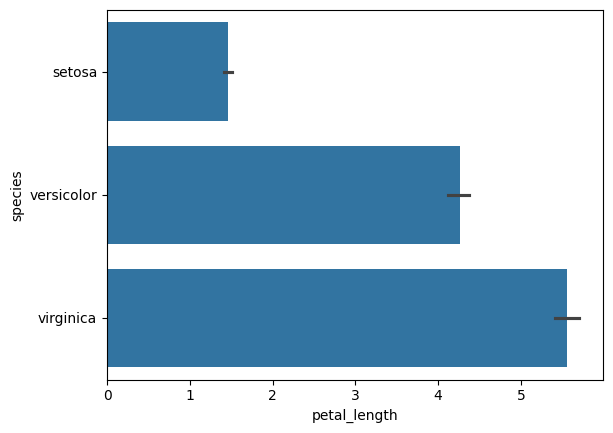

In [33]:
sns.barplot(iris, x="petal_length", y="species")

In [39]:
?sns.kdeplot

Signature:
sns.kdeplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    weights=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    color=None,
    fill=None,
    multiple='layer',
    common_norm=True,
    common_grid=False,
    cumulative=False,
    bw_method='scott',
    bw_adjust=1,
    warn_singular=True,
    log_scale=None,
    levels=10,
    thresh=0.05,
    gridsize=200,
    cut=3,
    clip=None,
    legend=True,
    cbar=False,
    cbar_ax=None,
    cbar_kws=None,
    ax=None,
    **kwargs,
)
Docstring:
Plot univariate or bivariate distributions using kernel density estimation.

A kernel density estimate (KDE) plot is a method for visualizing the
distribution of observations in a dataset, analogous to a histogram. KDE
represents the data using a continuous probability density curve in one or
more dimensions.

The approach is explained further in the :ref:`user guide <tutorial_kde>`.

Relative to a histogram, KDE can produce a plot that is less cl

<Axes: xlabel='petal_length', ylabel='Density'>

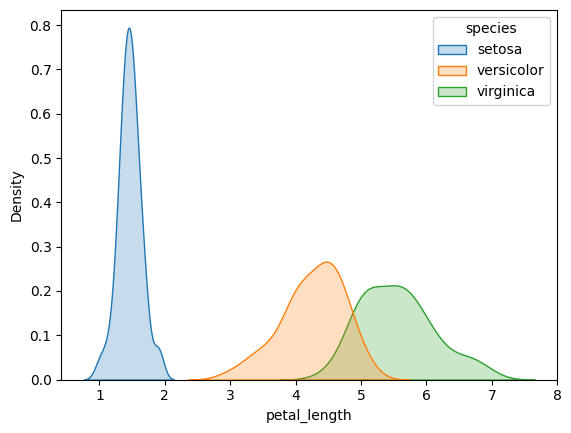

In [40]:
sns.kdeplot(iris, x="petal_length", hue="species", fill=True)

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

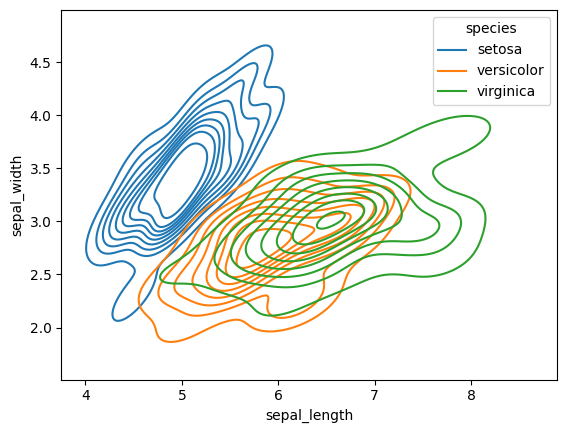

In [38]:
sns.kdeplot(iris, x="sepal_length", y="sepal_width", hue="species")

<Axes: xlabel='petal_length'>

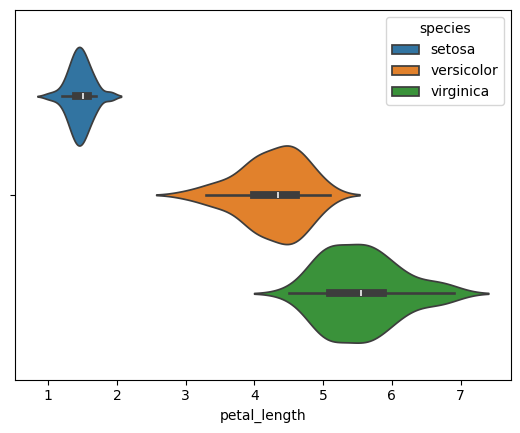

In [59]:
sns.violinplot(iris, x="petal_length", hue="species")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/eer

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/eer

AttributeError: _ARRAY_API not found

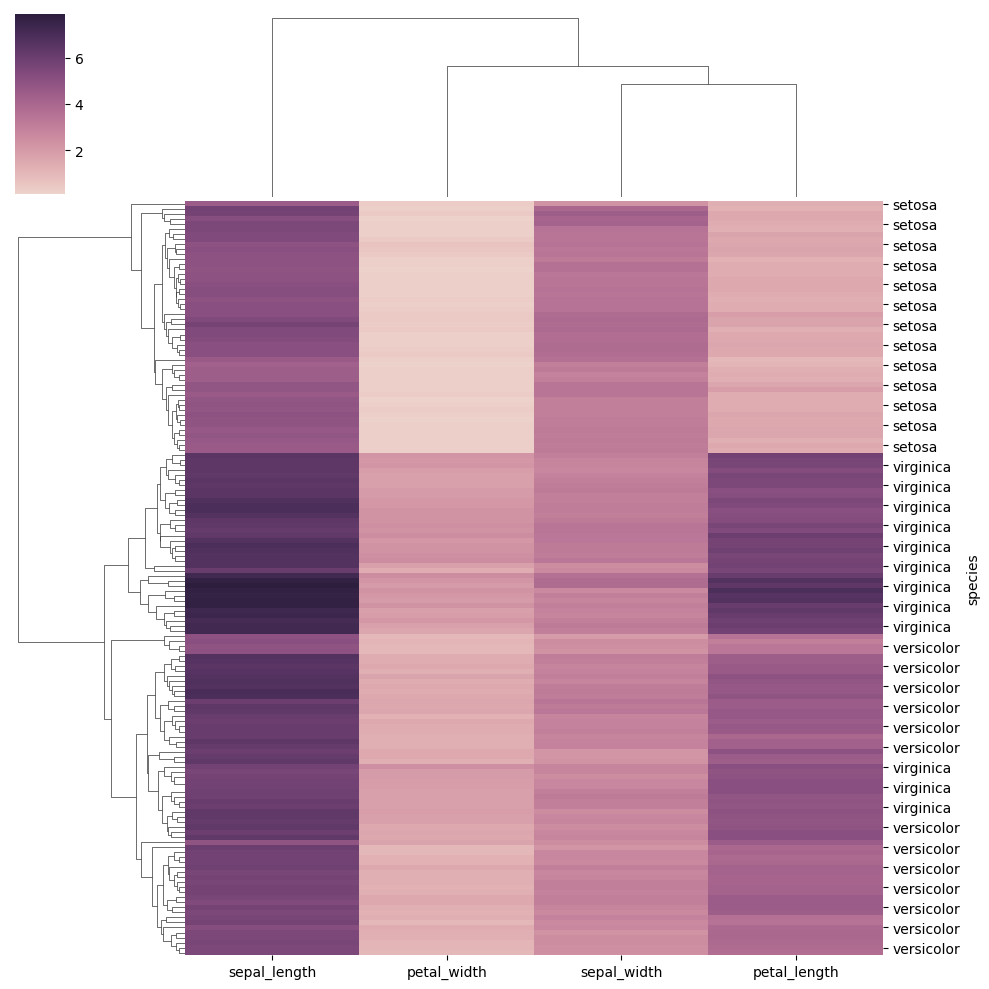

In [68]:
sns.clustermap(
    iris.set_index("species"),
    cmap=sns.cubehelix_palette(as_cmap=True)
)